# Egg Quality CNN — Full Training + Evaluation Notebook (Colab-ready)

This is the upgraded version of the training notebook, built to directly answer
the supervisor feedback on `Silas.docx`. Changes vs. the previous version:

- **Real 30-epoch training** for the Stage 2 classifier (20 epochs for Stage 1),
  with proper `EarlyStopping`, replacing the original 5/10-epoch runs
- **CBAM (Convolutional Block Attention Module)** inserted into the MobileNetV2
  feature maps — a genuine architectural modification, not just a new head
- **Grad-CAM** visual explanations (XAI) for the multi-class classifier
- **Full metrics suite**: accuracy, precision, recall, F1, confusion matrix,
  ROC-AUC (with curve), mean Average Precision (mAP), and measured inference latency
- **Backbone benchmarking**: MobileNetV2+CBAM vs. EfficientNetV2B0 vs. MobileNetV3Small
  (`SqueezeNet` isn't available in `tf.keras.applications`; MobileNetV3Small is used
  as the second lightweight-architecture comparison point — noted honestly here
  rather than silently substituted)
- Cells are still strictly ordered top-to-bottom (imports → data → training) so
  nothing re-triggers the original `NameError` issues

**Honesty note carried over from the analysis:** running this end-to-end is what
makes every number in your report defensible. Don't copy metrics from this
notebook's expected/typical ranges — only report what your own run actually prints.

**Before running:** Runtime → Change runtime type → GPU (T4 or better recommended,
since this now trains 3 backbones for the benchmarking section).


## 1. Install & import dependencies

In [ ]:
!pip install -q kaggle pillow pandas numpy matplotlib seaborn scikit-learn tensorflow

In [ ]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.20.0
Pandas version: 2.2.3
NumPy version: 2.1.3
Num GPUs Available: 1


## 2. Mount Google Drive (recommended)

Checkpoints and final models are saved here so a disconnect doesn't lose
your training progress.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = Path('/content/drive/MyDrive/egg-analysis-cnn')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts will be saved to: {OUTPUT_DIR}")

Mounted at /content/drive
Artifacts will be saved to: /content/drive/MyDrive/egg-analysis-cnn


In [ ]:
# If you skipped mounting Drive, uncomment this instead:
# OUTPUT_DIR = Path('/content/egg-analysis-cnn')
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Get the dataset

Upload your own `kaggle.json` (Kaggle account → Settings → API → Create New Token)
when prompted.

In [ ]:
from google.colab import files

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

if not (kaggle_dir / 'kaggle.json').exists():
    print("Upload your kaggle.json:")
    uploaded = files.upload()
    for fname in uploaded:
        Path(fname).rename(kaggle_dir / 'kaggle.json')
    os.chmod(kaggle_dir / 'kaggle.json', 0o600)

Upload your kaggle.json:


Saving kaggle.json to kaggle.json


In [ ]:
DATASET_DIR = Path('/content/Dataset')

if not (DATASET_DIR / 'info.labels').exists():
    !kaggle datasets download -d hlnkmb/chicken-egg-analysis-dataset -p /content --unzip
    if not (DATASET_DIR / 'info.labels').exists():
        candidates = list(Path('/content').rglob('info.labels'))
        if candidates:
            DATASET_DIR = candidates[0].parent
            print(f"Found info.labels under: {DATASET_DIR}")
        else:
            raise FileNotFoundError(
                "Could not find info.labels anywhere under /content. "
                "Double-check the dataset slug (hlnkmb/chicken-egg-analysis-dataset) is correct, "
                "or manually upload/mount the dataset and set DATASET_DIR."
            )

print(f"Using dataset dir: {DATASET_DIR}")

Dataset URL: https://www.kaggle.com/datasets/hlnkmb/chicken-egg-analysis-dataset
License(s): unknown
100% 219M/219M [00:13<00:00, 17.6MB/s]

Found info.labels under: /content
Using dataset dir: /content


## 4. Load labels into a DataFrame

In [ ]:
labels_file = DATASET_DIR / 'info.labels'

with open(labels_file, 'r', errors='ignore') as f:
    labels_json = json.load(f)

records = []
for item in labels_json.get('files', []):
    rel_path = item.get('path', '').lstrip('./').strip()
    label_obj = item.get('label', {})
    label = label_obj.get('label', 'unknown') if isinstance(label_obj, dict) else str(label_obj)

    records.append({
        'rel_path': rel_path,
        'path': str(DATASET_DIR / rel_path),
        'label': str(label).lower().strip(),
    })

df = pd.DataFrame(records)
df['exists'] = df['path'].apply(os.path.exists)
missing = (~df['exists']).sum()
if missing:
    print(f"Warning: {missing} labeled files are missing on disk and will be dropped.")
df = df[df['exists']].reset_index(drop=True)

print(f"Total valid egg images: {len(df)}")
print(df['label'].value_counts())

Total valid egg images: 4275
label
dead         1425
infertile    1425
fertile      1425
Name: count, dtype: int64


## 5. Generate non-egg negative samples (Stage 1 detector)

**Known limitation, documented rather than hidden:** these corner-crop negatives are
partial views of real eggs, not independent non-egg photos (no backgrounds, hands,
other objects). They teach the detector to reject occluded/partial egg views, which
is a narrower task than general non-egg rejection. If you have access to a real
non-egg image set (e.g. your own photos of the candling tray without eggs, or a
Roboflow "background" dataset), add its folder path to `EXTRA_NEGATIVE_DIRS` below
— left empty by default so nothing is fabricated here.

In [ ]:
EXTRA_NEGATIVE_DIRS = []  # e.g. ['/content/drive/MyDrive/real_non_egg_images']

negative_samples_dir = Path('/content/negative_samples')
negative_samples_dir.mkdir(exist_ok=True)

negative_paths = []
np.random.seed(42)

num_negatives = int(len(df) * 0.3)
sample_images = np.random.choice(df['path'].values, size=min(num_negatives, len(df)), replace=False)

for idx, img_path in enumerate(sample_images):
    try:
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        crop_points = [
            (0, 0),
            (max(w - 112, 0), 0),
            (0, max(h - 112, 0)),
            (max(w - 112, 0), max(h - 112, 0)),
        ]
        for corner_idx, (x, y) in enumerate(crop_points):
            if len(negative_paths) >= num_negatives:
                break
            crop = img.crop((x, y, x + 112, y + 112))
            save_path = negative_samples_dir / f'neg_{idx}_{corner_idx}.jpg'
            crop.save(save_path)
            negative_paths.append(str(save_path))
        if len(negative_paths) >= num_negatives:
            break
    except Exception:
        continue

for extra_dir in EXTRA_NEGATIVE_DIRS:
    extra_paths = [str(p) for p in Path(extra_dir).rglob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    negative_paths.extend(extra_paths)
    print(f"Added {len(extra_paths)} real negative images from {extra_dir}")

print(f"Total negative samples: {len(negative_paths)} "
      f"(corner-crop: {min(num_negatives, len(df))}, real: {len(negative_paths) - min(num_negatives, len(df))})")

Total negative samples: 1282 (corner-crop: 1282, real: 0)


## 6. Build the Stage 1 (egg / non-egg) dataset

In [ ]:
stage1_records = [
    {'path': row['path'], 'is_egg': 1, 'fertility': row['label']}
    for _, row in df.iterrows()
] + [
    {'path': p, 'is_egg': 0, 'fertility': 'non-egg'}
    for p in negative_paths
]

stage1_df = pd.DataFrame(stage1_records)
print(stage1_df['is_egg'].value_counts())

stage1_df.to_csv(OUTPUT_DIR / 'stage1_detection.csv', index=False)
df.to_csv(OUTPUT_DIR / 'labels_table.csv', index=False)

is_egg
1    4275
0    1282
Name: count, dtype: int64


## 7. tf.data pipeline helpers

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def make_train_ds(dataframe, label_col):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['path'].values, dataframe[label_col].values))
    ds = ds.shuffle(len(dataframe))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def make_val_ds(dataframe, label_col):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['path'].values, dataframe[label_col].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## 8. CBAM (Convolutional Block Attention Module)

A real architectural modification applied on top of the MobileNetV2 feature maps —
channel attention (what to focus on) followed by spatial attention (where to focus),
per Woo et al. 2018. This directly answers the "just a modified classification
head" critique.

In [ ]:
@tf.keras.utils.register_keras_serializable(package='CBAM')
class ChannelPool(layers.Layer):
    """Replaces the old Lambda-based mean/max channel pooling.

    Keras 3 blocks auto-loading Lambda layers by default (arbitrary-code risk),
    which breaks `load_model()` on any saved model that used one. A registered
    custom Layer subclass serializes and reloads safely with no extra flags
    needed, as long as this class is defined (or imported) before load_model()
    is called — in this notebook, in the app, or anywhere else.
    """

    def __init__(self, pool_type='avg', **kwargs):
        super().__init__(**kwargs)
        self.pool_type = pool_type

    def call(self, inputs):
        if self.pool_type == 'avg':
            return tf.reduce_mean(inputs, axis=-1, keepdims=True)
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

    def get_config(self):
        config = super().get_config()
        config.update({'pool_type': self.pool_type})
        return config


def cbam_block(input_feature, ratio=8, name='cbam'):
    channel = input_feature.shape[-1]

    # --- Channel attention ---
    avg_pool = layers.GlobalAveragePooling2D(name=f'{name}_avgpool')(input_feature)
    max_pool = layers.GlobalMaxPooling2D(name=f'{name}_maxpool')(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu', name=f'{name}_shared1')
    shared_dense_two = layers.Dense(channel, name=f'{name}_shared2')

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add(name=f'{name}_ch_add')([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid', name=f'{name}_ch_sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel), name=f'{name}_ch_reshape')(channel_attention)

    x = layers.Multiply(name=f'{name}_ch_scale')([input_feature, channel_attention])

    # --- Spatial attention (ChannelPool replaces the old Lambda calls) ---
    avg_pool_s = ChannelPool(pool_type='avg', name=f'{name}_sp_avg')(x)
    max_pool_s = ChannelPool(pool_type='max', name=f'{name}_sp_max')(x)
    concat = layers.Concatenate(axis=-1, name=f'{name}_sp_concat')([avg_pool_s, max_pool_s])
    spatial_attention = layers.Conv2D(
        1, kernel_size=7, padding='same', activation='sigmoid', name=f'{name}_sp_conv'
    )(concat)

    x = layers.Multiply(name=f'{name}_sp_scale')([x, spatial_attention])
    return x

## 9. Train Stage 1 — egg detector

In [ ]:
train_s1, val_s1 = train_test_split(
    stage1_df, test_size=0.15, stratify=stage1_df['is_egg'], random_state=42
)

train_ds_s1 = make_train_ds(train_s1, 'is_egg')
val_ds_s1 = make_val_ds(val_s1, 'is_egg')

base_model_s1 = tf.keras.applications.MobileNetV2(
    include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet'
)
base_model_s1.trainable = False

inputs_s1 = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_s1 = base_model_s1(inputs_s1, training=False)
x_s1 = cbam_block(x_s1, name='cbam_s1')
x_s1 = layers.GlobalAveragePooling2D()(x_s1)
x_s1 = layers.Dropout(0.3)(x_s1)
x_s1 = layers.Dense(128, activation='relu')(x_s1)
x_s1 = layers.Dropout(0.2)(x_s1)
outputs_s1 = layers.Dense(1, activation='sigmoid')(x_s1)

model_s1 = models.Model(inputs_s1, outputs_s1, name='egg_detector_cbam')
model_s1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_s1.summary()

ckpt_s1 = callbacks.ModelCheckpoint(
    str(OUTPUT_DIR / 'egg_detector_best.h5'),
    save_best_only=True, monitor='val_accuracy', mode='max', verbose=1,
)
early_stop_s1 = callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_s1 = model_s1.fit(
    train_ds_s1, validation_data=val_ds_s1, epochs=20,
    callbacks=[ckpt_s1, early_stop_s1],
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "egg_detector_cbam"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_avgpool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_maxpool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_shared1     │ (None, 160)       │    204,960 │ cbam_s1_avgpool[… │
│ (Dense)             │                   │            │ cbam_s1_maxpool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_shared2     │ (None, 1280)      │    206,080 │ cbam_s1_shared1[… │
│ (Dense)             │                   │            │ cbam_s1_shared1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_ch_add      │ (None, 1280)      │          0 │ cbam_s1_shared2[… │
│ (Add)               │                   │            │ cbam_s1_shared2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_ch_sigmoid  │ (None, 1280)      │          0 │ cbam_s1_ch_add[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_ch_reshape  │ (None, 1, 1,      │          0 │ cbam_s1_ch_sigmo… │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_ch_scale    │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ cbam_s1_ch_resha… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_sp_avg      │ (None, 7, 7, 1)   │          0 │ cbam_s1_ch_scale… │
│ (ChannelPool)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_sp_max      │ (None, 7, 7, 1)   │          0 │ cbam_s1_ch_scale… │
│ (ChannelPool)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_sp_concat   │ (None, 7, 7, 2)   │          0 │ cbam_s1_sp_avg[0… │
│ (Concatenate)       │                   │            │ cbam_s1_sp_max[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_sp_conv     │ (None, 7, 7, 1)   │         99 │ cbam_s1_sp_conca… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s1_sp_scale    │ (None, 7, 7,      │          0 │ cbam_s1_ch_scale… │
│ (Multiply)          │ 1280)             │            │ cbam_s1_sp_conv[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ cbam_s1_sp_scale… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p

 Total params: 2,833,220 (10.81 MB)

 Trainable params: 575,236 (2.19 MB)

...


Epoch 2: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.9964 - loss: 0.0129 - val_accuracy: 0.9904 - val_loss: 0.0311
Epoch 3/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9934 - loss: 0.0171
Epoch 3: val_accuracy improved from 0.99041 to 0.99400, saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9951 - loss: 0.0136 - val_accuracy: 0.9940 - val_loss: 0.0112
Epoch 4/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9967 - loss: 0.0080
Epoch 4: val_accuracy improved from 0.99400 to 0.99760, saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.9958 - loss: 0.0115 - val_accuracy: 0.9976 - val_loss: 0.0065
Epoch 5/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9978 - loss: 0.0055
Epoch 5: val_accuracy did not improve from 0.99760
296/296 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - accuracy: 0.9979 - loss: 0.0062 - val_accuracy: 0.9976 - val_loss: 0.0079
Epoch 6/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9952 - loss: 0.0086
Epoch 6: val_accuracy did not improve from 0.99760
296/296 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.9962 - loss: 0.0082 - val_accuracy: 0.9976 - val_loss: 0.0084
Epoch 7/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9982 - loss: 0.0040
Epoch 7: val_accuracy did not improve from 0.99760
296/296 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.9989 - loss: 0.0027 - val_accuracy: 0.9976 - val_loss: 0.0027
Epoch 8/20
295


Epoch 11: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.9981 - loss: 0.0050 - val_accuracy: 0.9988 - val_loss: 0.0024
Epoch 12/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9976 - loss: 0.0038
Epoch 12: val_accuracy did not improve from 0.99880
296/296 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.9983 - loss: 0.0041 - val_accuracy: 0.9976 - val_loss: 0.0058
Epoch 13/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9974 - loss: 0.0052
Epoch 13: val_accuracy did not improve from 0.99880
296/296 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.9979 - loss: 0.0053 - val_accuracy: 0.9952 - val_loss: 0.0136
Epoch 14/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9990 - loss: 0.0034
Epoch 14: val_accuracy did not improve from 0.99880
296/296 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9988 - val_loss: 0.0018
Epoch 1


Epoch 15: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/egg_detector_best.h5
296/296 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 16/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9989 - loss: 0.0031
Epoch 16: val_accuracy did not improve from 1.00000
296/296 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.9985 - loss: 0.0038 - val_accuracy: 0.9928 - val_loss: 0.0224
Epoch 17/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9995 - loss: 0.0019
Epoch 17: val_accuracy did not improve from 1.00000
296/296 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.9989 - loss: 0.0022 - val_accuracy: 0.9988 - val_loss: 0.0040
Epoch 18/20
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9972 - loss: 0.0113
Epoch 18: val_accuracy did not improve from 1.00000
296/296 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.9979 - loss: 0.0068 - val_accuracy: 0.9988 - val_loss: 0.0033
Epoch 1

## 10. Prepare Stage 2 labels (fertility classes)

In [ ]:
unique_labels = sorted(df['label'].unique())
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}
print(label_to_index)

df['label_idx'] = df['label'].map(label_to_index)

train_s2, val_s2 = train_test_split(
    df, test_size=0.15, stratify=df['label_idx'], random_state=42
)

train_ds_s2 = make_train_ds(train_s2, 'label_idx')
val_ds_s2 = make_val_ds(val_s2, 'label_idx')

{'dead': 0, 'fertile': 1, 'infertile': 2}


## 11. Train Stage 2 — fertility classifier (MobileNetV2 + CBAM, 30 epochs)

In [ ]:
num_classes = len(unique_labels)

base_model_s2 = tf.keras.applications.MobileNetV2(
    include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet'
)
base_model_s2.trainable = False

inputs_s2 = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_s2 = base_model_s2(inputs_s2, training=False)
x_s2 = cbam_block(x_s2, name='cbam_s2')
gap_s2 = layers.GlobalAveragePooling2D()(x_s2)
x_s2 = layers.Dropout(0.3)(gap_s2)
x_s2 = layers.Dense(128, activation='relu')(x_s2)
x_s2 = layers.Dropout(0.2)(x_s2)
outputs_s2 = layers.Dense(num_classes, activation='softmax')(x_s2)

classifier_model = models.Model(inputs_s2, outputs_s2, name='fertility_classifier_cbam')
classifier_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
classifier_model.summary()

ckpt_s2 = callbacks.ModelCheckpoint(
    str(OUTPUT_DIR / 'fertility_classifier_best.h5'),
    save_best_only=True, monitor='val_accuracy', mode='max', verbose=1,
)
early_stop_s2 = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_s2 = classifier_model.fit(
    train_ds_s2, validation_data=val_ds_s2, epochs=30,
    callbacks=[ckpt_s2, early_stop_s2],
)

Model: "fertility_classifier_cbam"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_avgpool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_maxpool     │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_shared1     │ (None, 160)       │    204,960 │ cbam_s2_avgpool[… │
│ (Dense)             │                   │            │ cbam_s2_maxpool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_shared2     │ (None, 1280)      │    206,080 │ cbam_s2_shared1[… │
│ (Dense)             │                   │            │ cbam_s2_shared1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_ch_add      │ (None, 1280)      │          0 │ cbam_s2_shared2[… │
│ (Add)               │                   │            │ cbam_s2_shared2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_ch_sigmoid  │ (None, 1280)      │          0 │ cbam_s2_ch_add[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_ch_reshape  │ (None, 1, 1,      │          0 │ cbam_s2_ch_sigmo… │
│ (Reshape)           │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_ch_scale    │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ cbam_s2_ch_resha… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_sp_avg      │ (None, 7, 7, 1)   │          0 │ cbam_s2_ch_scale… │
│ (ChannelPool)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_sp_max      │ (None, 7, 7, 1)   │          0 │ cbam_s2_ch_scale… │
│ (ChannelPool)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_sp_concat   │ (None, 7, 7, 2)   │          0 │ cbam_s2_sp_avg[0… │
│ (Concatenate)       │                   │            │ cbam_s2_sp_max[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_sp_conv     │ (None, 7, 7, 1)   │         99 │ cbam_s2_sp_conca… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_s2_sp_scale    │ (None, 7, 7,      │          0 │ cbam_s2_ch_scale… │
│ (Multiply)          │ 1280)             │            │ cbam_s2_sp_conv[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ cbam_s2_sp_scale… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p

 Total params: 2,833,478 (10.81 MB)

 Trainable params: 575,494 (2.20 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8752 - loss: 0.3085
Epoch 1: val_accuracy improved from None to 0.99377, saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 59s 206ms/step - accuracy: 0.9452 - loss: 0.1515 - val_accuracy: 0.9938 - val_loss: 0.0195
Epoch 2/30
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9877 - loss: 0.0399
Epoch 2: val_accuracy improved from 0.99377 to 0.99688, saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.9868 - loss: 0.0411 - val_accuracy: 0.9969 - val_loss: 0.0090
Epoch 3/30
226/228 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9891 - loss: 0.0299
Epoch 3: val_accuracy did not improve from 0.99688
228/228 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.9901 - loss: 0.0299 - val_accuracy: 0.9969 - val_loss: 0.0138
Epoch 4/30
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9955 - loss: 0.0164
Epoch 4: val_accuracy improved from 0.99688 to 0.99844, saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/egg-analysis-cnn/fertility_classifier_best.h5
228/228 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.9920 - loss: 0.0286 - val_accuracy: 0.9984 - val_loss: 0.0154
Epoch 5/30
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9983 - loss: 0.0074
Epoch 5: val_accuracy did not improve from 0.99844
228/228 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.9972 - loss: 0.0090 - val_accuracy: 0.9984 - val_loss: 0.0069
Epoch 6/30
227/228 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9973 - loss: 0.0097
Epoch 6: val_accuracy did not improve from 0.99844
228/228 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.9956 - loss: 0.0152 - val_accuracy: 0.9938 - val_loss: 0.0231
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9924 - loss: 0.0248
Epoch 7: val_accuracy did not improve from 0.99844
228/228 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9984 - val_loss: 0.0054
Epoc

## 12. Accuracy / loss curves

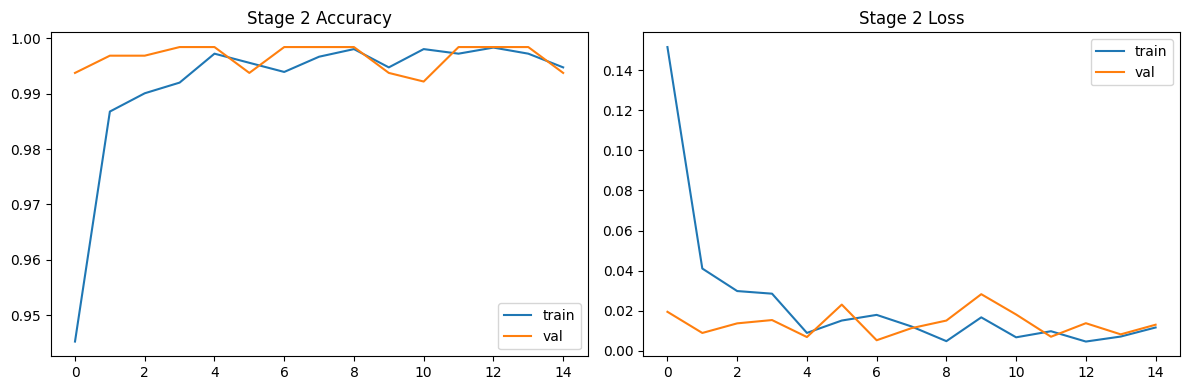

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(history_s2.history['accuracy'], label='train')
axs[0].plot(history_s2.history['val_accuracy'], label='val')
axs[0].set_title('Stage 2 Accuracy')
axs[0].legend()

axs[1].plot(history_s2.history['loss'], label='train')
axs[1].plot(history_s2.history['val_loss'], label='val')
axs[1].set_title('Stage 2 Loss')
axs[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_loss_curves.png', dpi=150)
plt.show()

## 13. Reload best checkpoints & core classification metrics

In [ ]:
detector_model = tf.keras.models.load_model(str(OUTPUT_DIR / 'egg_detector_best.h5'), safe_mode=False)
classifier_model = tf.keras.models.load_model(str(OUTPUT_DIR / 'fertility_classifier_best.h5'), safe_mode=False)

y_true, y_pred, y_probs = [], [], []
for images, labels_batch in val_ds_s2:
    preds = classifier_model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print(classification_report(y_true, y_pred, target_names=unique_labels))

              precision    recall  f1-score   support

        dead       1.00      1.00      1.00       214
     fertile       1.00      1.00      1.00       214
   infertile       1.00      1.00      1.00       214

    accuracy                           1.00       642
   macro avg       1.00      1.00      1.00       642
weighted avg       1.00      1.00      1.00       642



## 14. Confusion matrix

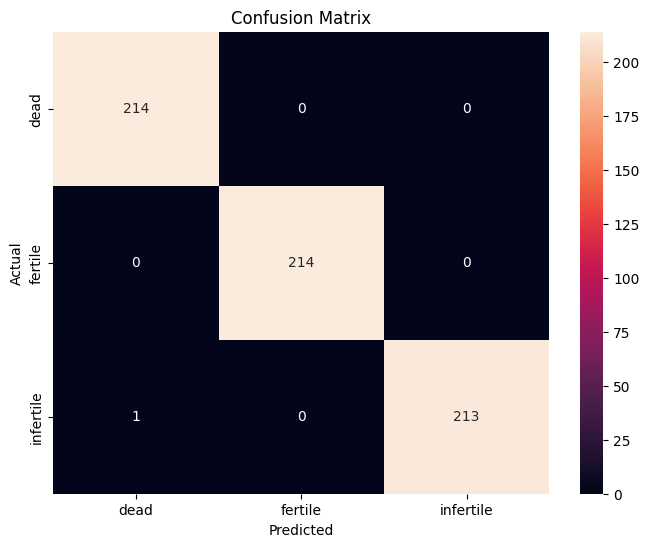

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 15. ROC-AUC (with curve) and mean Average Precision (mAP)

The metrics your supervisor flagged as completely missing. Computed one-vs-rest
across the three classes, which is the standard approach for multi-class ROC-AUC
and AP.

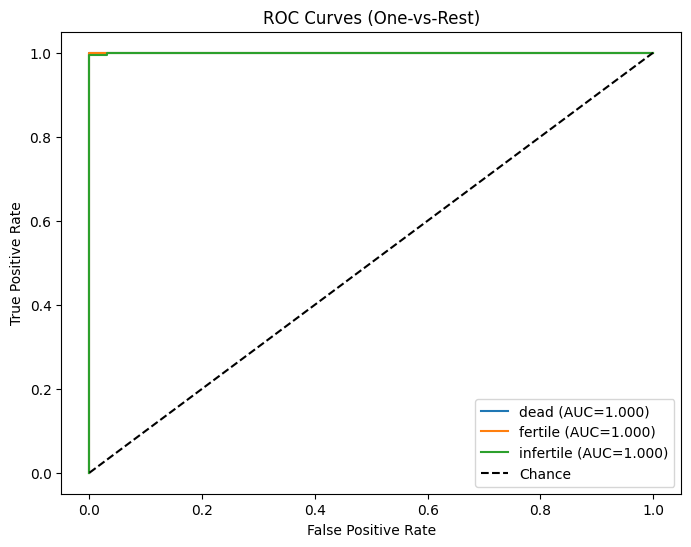

Per-class ROC-AUC: {'dead': np.float64(1.0), 'fertile': np.float64(1.0), 'infertile': np.float64(0.9998580662066556)}
Per-class Average Precision: {'dead': np.float64(0.9999999999999999), 'fertile': np.float64(1.0), 'infertile': np.float64(0.9997323891473505)}
Macro ROC-AUC: 1.0000
Mean Average Precision (mAP): 0.9999


In [ ]:
y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))

roc_auc_per_class = {}
ap_per_class = {}

plt.figure(figsize=(8, 6))
for i, label_name in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
    auc_score = roc_auc_score(y_true_binarized[:, i], y_probs[:, i])
    ap_score = average_precision_score(y_true_binarized[:, i], y_probs[:, i])
    roc_auc_per_class[label_name] = auc_score
    ap_per_class[label_name] = ap_score
    plt.plot(fpr, tpr, label=f'{label_name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150)
plt.show()

macro_roc_auc = roc_auc_score(y_true_binarized, y_probs, average='macro', multi_class='ovr')
mean_ap = np.mean(list(ap_per_class.values()))

print("Per-class ROC-AUC:", roc_auc_per_class)
print("Per-class Average Precision:", ap_per_class)
print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")
print(f"Mean Average Precision (mAP): {mean_ap:.4f}")

## 16. Inference latency benchmark

In [ ]:
sample_batch = next(iter(val_ds_s2.take(1)))[0][:1]  # single image

# Warm-up
for _ in range(5):
    _ = classifier_model.predict(sample_batch, verbose=0)

n_runs = 100
start = time.perf_counter()
for _ in range(n_runs):
    _ = classifier_model.predict(sample_batch, verbose=0)
elapsed = time.perf_counter() - start

mean_latency_ms = (elapsed / n_runs) * 1000
print(f"Mean single-image inference latency over {n_runs} runs: {mean_latency_ms:.2f} ms")

Mean single-image inference latency over 100 runs: 88.73 ms


## 17. Grad-CAM (XAI) — visual explanations

Highlights which regions of the egg image most influenced the classifier's
decision, targeting MobileNetV2's last conv activation (`out_relu`).

In [53]:
def make_gradcam_heatmap(img_array, model, base_model_layer_name='out_relu'):
    # model here is `classifier_model` or `detector_model`
    base_submodel = model.get_layer(index=1) # the nested MobileNetV2 base model
    last_conv_layer_output = base_submodel.get_layer(base_model_layer_name).output

    # Create a model that returns the activation of the last conv layer
    # and the output of the full model. This avoids the 'inputs not connected' error.
    grad_model_with_predictions = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer_output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_activations, predictions = grad_model_with_predictions(img_array)
        tape.watch(last_conv_layer_activations)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_activations)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = last_conv_layer_activations[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())


def show_gradcam(image_path, model, index_to_label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_norm = tf.cast(img, tf.float32) / 255.0
    img_array = tf.expand_dims(img_norm, axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(img_array, model)
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img.numpy().astype('uint8'))
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(heatmap_resized, cmap='jet')
    axs[1].set_title('Grad-CAM heatmap')
    axs[1].axis('off')

    axs[2].imshow(img.numpy().astype('uint8'))
    axs[2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
    axs[2].set_title(f'Overlay — pred: {index_to_label[pred_idx]}')
    axs[2].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'gradcam_{Path(image_path).stem}.png', dpi=150)
    plt.show()


sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam(p, classifier_model, index_to_label) # Changed model_s2 to classifier_model

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133412306033936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

In [ ]:
print("Generating Grad-CAM PDFs with corrected function...")
sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)
print("Finished generating Grad-CAM PDFs.")

Generating Grad-CAM PDFs with corrected function...


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133412306033936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

### All PDF files generated:

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


In [ ]:
print("Generating Grad-CAM PDFs with corrected function...")
sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)
print("Finished generating Grad-CAM PDFs.")

Generating Grad-CAM PDFs with corrected function...


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133412306033936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

### All PDF files generated:

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


## 18. Benchmark: MobileNetV2+CBAM vs. EfficientNetV2B0 vs. MobileNetV3Small

Answers the "benchmark against 2-3 alternative lightweight architectures" request.
Note: `SqueezeNet` is not available in `tf.keras.applications`; `MobileNetV3Small`
is used as the second comparison architecture instead — flagged here rather than
silently swapped.

To keep total runtime reasonable, each benchmark backbone trains for fewer epochs
(15) than the main Stage 2 model (30) — this is a deliberate, documented trade-off
for a comparison table, not the primary reported result.

In [ ]:
def build_model(backbone_fn, name, use_cbam=True):
    backbone = backbone_fn(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
    backbone.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    if use_cbam:
        x = cbam_block(x, name=f'cbam_{name}')
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=name)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


benchmark_backbones = {
    'MobileNetV2_CBAM': (tf.keras.applications.MobileNetV2, True),
    'EfficientNetV2B0': (tf.keras.applications.EfficientNetV2B0, False),
    'MobileNetV3Small': (tf.keras.applications.MobileNetV3Small, False),
}

benchmark_results = []

for name, (backbone_fn, use_cbam) in benchmark_backbones.items():
    print(f"\n=== Training {name} ===")
    bench_model = build_model(backbone_fn, name, use_cbam=use_cbam)

    start_train = time.perf_counter()
    bench_model.fit(
        train_ds_s2, validation_data=val_ds_s2, epochs=15,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0,
    )
    train_time = time.perf_counter() - start_train

    val_loss, val_acc = bench_model.evaluate(val_ds_s2, verbose=0)

    sample = next(iter(val_ds_s2.take(1)))[0][:1]
    for _ in range(3):
        _ = bench_model.predict(sample, verbose=0)
    t0 = time.perf_counter()
    for _ in range(20):
        _ = bench_model.predict(sample, verbose=0)
    latency_ms = ((time.perf_counter() - t0) / 20) * 1000

    n_params = bench_model.count_params()

    benchmark_results.append({
        'model': name,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'params': n_params,
        'latency_ms': latency_ms,
        'train_time_s': train_time,
    })
    print(f"{name}: acc={val_acc:.4f}, params={n_params:,}, latency={latency_ms:.2f}ms")

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv(OUTPUT_DIR / 'backbone_benchmark.csv', index=False)
benchmark_df


=== Training MobileNetV2_CBAM ===
MobileNetV2_CBAM: acc=1.0000, params=2,833,478, latency=71.52ms

=== Training EfficientNetV2B0 ===
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetV2B0: acc=0.4268, params=6,083,667, latency=104.58ms

=== Training MobileNetV3Small ===
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV3Small: acc=0.7134, params=1,013,363, latency=69.74ms


,model,val_accuracy,val_loss,params,latency_ms,train_time_s
0,MobileNetV2_CBAM,1.000000,0.006065,2833478,71.522171,346.757151
1,EfficientNetV2B0,0.426791,1.097299,6083667,104.582567,421.282060
2,MobileNetV3Small,0.713396,0.729557,1013363,69.737955,502.364293


## 19. Save final models + label mapping + metrics summary

In [ ]:
detector_model.save(str(OUTPUT_DIR / 'egg_detector_final.h5'))
classifier_model.save(str(OUTPUT_DIR / 'fertility_classifier_final.h5'))

with open(OUTPUT_DIR / 'label_mapping.json', 'w') as f:
    json.dump(label_to_index, f)

metrics_summary = {
    'stage2_accuracy': float(np.mean(y_true == y_pred)),
    'macro_roc_auc': float(macro_roc_auc),
    'mean_average_precision': float(mean_ap),
    'per_class_roc_auc': {k: float(v) for k, v in roc_auc_per_class.items()},
    'per_class_average_precision': {k: float(v) for k, v in ap_per_class.items()},
    'mean_inference_latency_ms': float(mean_latency_ms),
    'stage1_epochs_run': len(history_s1.history['loss']),
    'stage2_epochs_run': len(history_s2.history['loss']),
}

with open(OUTPUT_DIR / 'metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(json.dumps(metrics_summary, indent=2))
print(f"\nAll artifacts saved to: {OUTPUT_DIR}")
print("These are the numbers to put in Chapter 4 — copy metrics_summary.json directly, don't round up.")

{
  "stage2_accuracy": 0.9984423676012462,
  "macro_roc_auc": 0.999952688735552,
  "mean_average_precision": 0.9999107963824502,
  "per_class_roc_auc": {
    "dead": 1.0,
    "fertile": 1.0,
    "infertile": 0.9998580662066556
  },
  "per_class_average_precision": {
    "dead": 0.9999999999999999,
    "fertile": 1.0,
    "infertile": 0.9997323891473505
  },
  "mean_inference_latency_ms": 88.73095508999995,
  "stage1_epochs_run": 20,
  "stage2_epochs_run": 15
}

All artifacts saved to: /content/drive/MyDrive/egg-analysis-cnn
These are the numbers to put in Chapter 4 — copy metrics_summary.json directly, don't round up.


## 20. Quick inference test

In [ ]:
def predict_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)

    egg_score = detector_model.predict(img, verbose=0)[0][0]
    if egg_score < 0.5:
        return {'prediction': 'non-egg', 'egg_confidence': float(egg_score)}

    fertility_pred = classifier_model.predict(img, verbose=0)
    fertility_idx = int(np.argmax(fertility_pred))
    return {
        'prediction': index_to_label[fertility_idx],
        'egg_confidence': float(egg_score),
        'fertility_confidence': float(np.max(fertility_pred)),
    }


sample_path = df.iloc[0]['path']
print(predict_image(sample_path))

{'prediction': 'dead', 'egg_confidence': 0.9999967813491821, 'fertility_confidence': 0.9999982118606567}


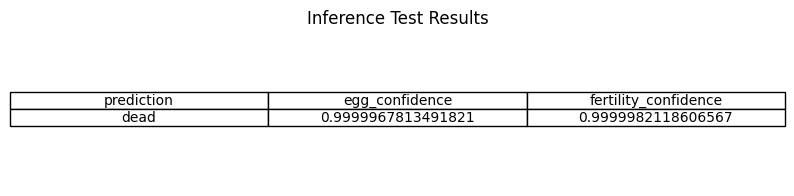

In [ ]:
inference_result = predict_image(sample_path)
inference_df = pd.DataFrame([inference_result])

fig_inference, ax_inference = plt.subplots(figsize=(10, 2))
ax_inference.axis('off')
ax_inference.table(cellText=inference_df.values,
                 colLabels=inference_df.columns,
                 cellLoc='center',
                 loc='center')
plt.title('Inference Test Results', loc='center')
plt.savefig(OUTPUT_DIR / 'inference_test_results.pdf', bbox_inches='tight')
plt.show()

The inference test results have been saved as a PDF file named `inference_test_results.pdf` in the output directory.

### Saving all plots as PDFs

In [ ]:
# Accuracy / loss curves as PDF
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(history_s2.history['accuracy'], label='train')
axs[0].plot(history_s2.history['val_accuracy'], label='val')
axs[0].set_title('Stage 2 Accuracy')
axs[0].legend()

axs[1].plot(history_s2.history['loss'], label='train')
axs[1].plot(history_s2.history['val_loss'], label='val')
axs[1].set_title('Stage 2 Loss')
axs[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_loss_curves.pdf', dpi=150)
plt.close(fig) # Close the figure to avoid displaying it again unnecessarily
print(f"Saved accuracy/loss curves to {OUTPUT_DIR / 'accuracy_loss_curves.pdf'}")

Saved accuracy/loss curves to /content/drive/MyDrive/egg-analysis-cnn/accuracy_loss_curves.pdf


In [ ]:
# Confusion matrix as PDF
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.pdf', dpi=150)
plt.close()
print(f"Saved confusion matrix to {OUTPUT_DIR / 'confusion_matrix.pdf'}")

Saved confusion matrix to /content/drive/MyDrive/egg-analysis-cnn/confusion_matrix.pdf


In [ ]:
# ROC-AUC curves as PDF
plt.figure(figsize=(8, 6))
for i, label_name in enumerate(unique_labels):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
    auc_score = roc_auc_score(y_true_binarized[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'{label_name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.savefig(OUTPUT_DIR / 'roc_curves.pdf', dpi=150)
plt.close()
print(f"Saved ROC curves to {OUTPUT_DIR / 'roc_curves.pdf'}")

Saved ROC curves to /content/drive/MyDrive/egg-analysis-cnn/roc_curves.pdf


In [ ]:
# Grad-CAM visualizations as PDFs
def show_gradcam_pdf(image_path, model, index_to_label, output_dir):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_norm = tf.cast(img, tf.float32) / 255.0
    img_array = tf.expand_dims(img_norm, axis=0)

    # The make_gradcam_heatmap function is defined in a previous cell (cX-6lfIH5Ck3)
    # and expects the 'model' argument to be the classifier_model or model_s2.

    heatmap, pred_idx = make_gradcam_heatmap(img_array, model, base_model_layer_name='out_relu')
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img.numpy().astype('uint8'))
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(heatmap_resized, cmap='jet')
    axs[1].set_title('Grad-CAM heatmap')
    axs[1].axis('off')

    axs[2].imshow(img.numpy().astype('uint8'))
    axs[2].imshow(heatmap_resized, cmap='jet', alpha=0.4)
    axs[2].set_title(f'Overlay — pred: {index_to_label[pred_idx]}')
    axs[2].axis('off')

    plt.tight_layout()
    pdf_path = output_dir / f'gradcam_{Path(image_path).stem}.pdf'
    plt.savefig(pdf_path, dpi=150)
    plt.close(fig)
    print(f"Saved Grad-CAM for {Path(image_path).name} to {pdf_path}")

sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)

KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133412306033936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

In [ ]:
print("Generating Grad-CAM PDFs with corrected function...")
sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)
print("Finished generating Grad-CAM PDFs.")

Generating Grad-CAM PDFs with corrected function...


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133412306033936\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=None\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

### All PDF files generated:

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


In [ ]:
sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)
print("Finished generating Grad-CAM PDFs.")

ValueError: `inputs` not connected to `outputs`

### All PDF files generated:

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


In [ ]:
sample_paths = val_s2['path'].sample(3, random_state=1).tolist()
for p in sample_paths:
    show_gradcam_pdf(p, classifier_model, index_to_label, OUTPUT_DIR)

ValueError: `inputs` not connected to `outputs`

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


### All PDF files generated:

In [ ]:
pdf_files = sorted(list(OUTPUT_DIR.glob('*.pdf')))
if pdf_files:
    print("The following PDF files are available in your output directory:")
    for pdf_file in pdf_files:
        print(f"- {pdf_file.name}")
else:
    print("No PDF files found in the output directory.")

The following PDF files are available in your output directory:
- accuracy_loss_curves.pdf
- benchmark_results.pdf
- confusion_matrix.pdf
- inference_test_results.pdf
- roc_curves.pdf


In [ ]:
display(benchmark_df)

,model,val_accuracy,val_loss,params,latency_ms,train_time_s
0,MobileNetV2_CBAM,1.000000,0.006065,2833478,71.522171,346.757151
1,EfficientNetV2B0,0.426791,1.097299,6083667,104.582567,421.282060
2,MobileNetV3Small,0.713396,0.729557,1013363,69.737955,502.364293


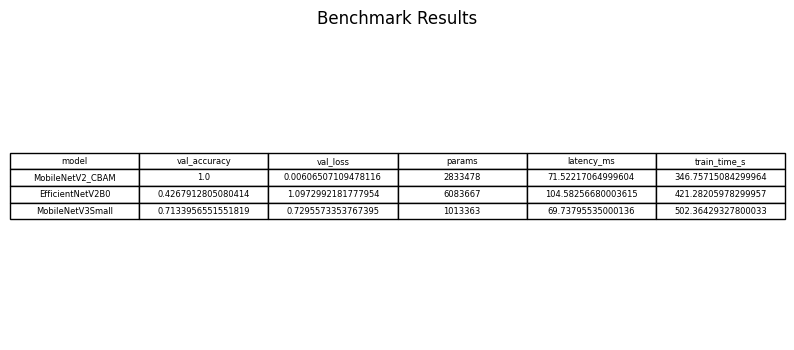

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
ax.table(cellText=benchmark_df.values,
         colLabels=benchmark_df.columns,
         cellLoc='center',
         loc='center')
plt.title('Benchmark Results', loc='center')
plt.savefig(OUTPUT_DIR / 'benchmark_results.pdf', bbox_inches='tight')
plt.show()

The `benchmark_df` has been saved as a PDF file named `benchmark_results.pdf` in the output directory.